<a href="https://colab.research.google.com/github/harishdcse2025-hash/INTERPOLATION-SEARCH/blob/main/DAA_Exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Array Size: 5000
Target Roll Number: 8084
--------------------------------------------------
Binary Search
Index Found : 4055
Probes Used : 13
--------------------------------------------------
Interpolation Search
Index Found : 4055
Probes Used : 4
--------------------------------------------------
Interpolation Search is more efficient for this search.


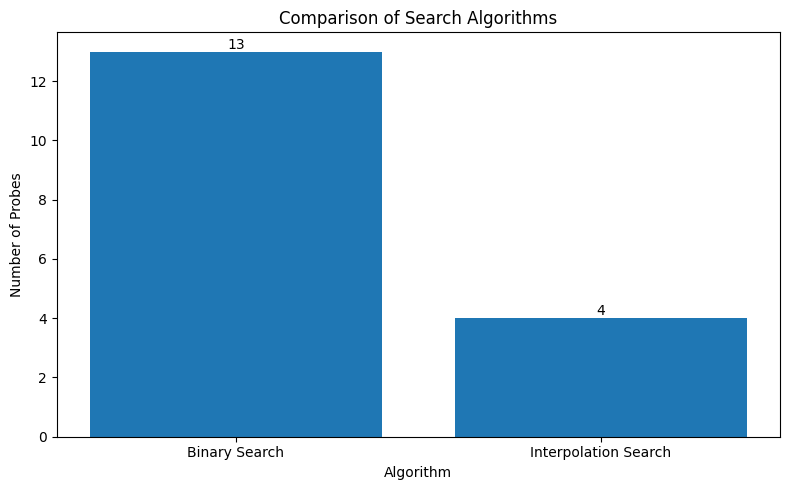

In [2]:
import random
import matplotlib.pyplot as plt


def binary_search(arr, target):
    low = 0
    high = len(arr) - 1
    probes = 0

    while low <= high:
        probes += 1
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid, probes
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1, probes


def interpolation_search(arr, target):
    low = 0
    high = len(arr) - 1
    probes = 0

    while low <= high and arr[low] <= target <= arr[high]:
        probes += 1

        if arr[high] == arr[low]:
            if arr[low] == target:
                return low, probes
            break

        pos = low + int(
            ((float(high - low) / (arr[high] - arr[low]))
             * (target - arr[low]))
        )

        if arr[pos] == target:
            return pos, probes
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1, probes


# -------------------------
# Main Program
# -------------------------
if __name__ == "__main__":

    # Generate sorted roll numbers
    array_size = 5000
    student_rolls = sorted(
        random.sample(range(1, 10001), array_size)
    )

    # Choose a target roll number
    target_index = random.randint(0, array_size - 1)
    target_roll = student_rolls[target_index]

    print(f"\nArray Size: {array_size}")
    print(f"Target Roll Number: {target_roll}")
    print("-" * 50)

    # Binary Search
    bs_idx, bs_probes = binary_search(
        student_rolls,
        target_roll
    )

    print("Binary Search")
    print(f"Index Found : {bs_idx}")
    print(f"Probes Used : {bs_probes}")

    print("-" * 50)

    # Interpolation Search
    is_idx, is_probes = interpolation_search(
        student_rolls,
        target_roll
    )

    print("Interpolation Search")
    print(f"Index Found : {is_idx}")
    print(f"Probes Used : {is_probes}")

    print("-" * 50)

    # Comparison Result
    if bs_probes < is_probes:
        print("Binary Search is more efficient for this search.")
    elif is_probes < bs_probes:
        print("Interpolation Search is more efficient for this search.")
    else:
        print("Both algorithms performed equally.")

    # -------------------------
    # Plot Comparison Chart
    # -------------------------

    algorithms = ["Binary Search", "Interpolation Search"]
    probes = [bs_probes, is_probes]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(algorithms, probes)

    plt.title("Comparison of Search Algorithms")
    plt.ylabel("Number of Probes")
    plt.xlabel("Algorithm")

    # Display values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            str(height),
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()